In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/playground-series-s6e6/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e6/train.csv
/kaggle/input/competitions/playground-series-s6e6/test.csv


In [2]:
import pandas as pd

In [3]:
train_df = pd.read_csv('/kaggle/input/competitions/playground-series-s6e6/train.csv')
display(train_df.sample(5))
test_df = pd.read_csv('/kaggle/input/competitions/playground-series-s6e6/test.csv')
display(test_df.sample(5))


,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
506045,506045,239.407628,33.176427,21.850304,21.916655,21.533797,21.871466,21.497714,1.772858,A/F,Blue_Cloud,QSO
336044,336044,229.996524,38.849542,23.548920,22.140133,20.688381,19.550805,18.481330,0.616777,M,Red_Sequence,GALAXY
181760,181760,17.267597,-4.206670,25.457846,21.613924,19.923620,19.439165,18.645888,0.499100,M,Red_Sequence,GALAXY
184555,184555,222.771633,13.492146,20.384478,18.910380,17.369611,17.379310,16.884098,0.051186,M,Red_Sequence,GALAXY
148012,148012,249.928978,41.527781,22.528707,21.333681,20.316828,20.222094,19.779257,0.048760,M,Red_Sequence,STAR


,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population
147367,724714,56.683561,0.788279,23.651516,22.410616,20.405653,19.391106,18.706643,0.008458,M,Red_Sequence
197792,775139,201.927779,7.193516,19.489556,18.056983,17.252993,17.309066,16.568793,0.263048,G/K,Red_Sequence
237062,814409,221.482062,31.567318,24.912487,21.858306,20.378874,19.400477,18.855308,0.275036,M,Red_Sequence
186325,763672,246.917722,46.824922,21.664743,21.695337,21.409415,21.457842,21.217532,2.226362,A/F,Blue_Cloud
29456,606803,6.818713,-2.878128,26.906301,22.600843,20.948923,19.638545,19.086580,0.155528,M,Red_Sequence


In [6]:
train_df.shape

(577347, 12)

In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 577347 non-null  int64  
 1   alpha              577347 non-null  float64
 2   delta              577347 non-null  float64
 3   u                  577347 non-null  float64
 4   g                  577347 non-null  float64
 5   r                  577347 non-null  float64
 6   i                  577347 non-null  float64
 7   z                  577347 non-null  float64
 8   redshift           577347 non-null  float64
 9   spectral_type      577347 non-null  object 
 10  galaxy_population  577347 non-null  object 
 11  class              577347 non-null  object 
dtypes: float64(8), int64(1), object(3)
memory usage: 52.9+ MB


In [8]:
train_df.columns

Index(['id', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift',
       'spectral_type', 'galaxy_population', 'class'],
      dtype='object')

In [5]:
from sklearn.preprocessing import LabelEncoder

In [9]:
for cols in ['spectral_type', 'galaxy_population']:
    le = LabelEncoder()
    train_df[f'{cols}_le'] = le.fit_transform(train_df[cols])
    test_df[f'{cols}_le'] = le.transform(test_df[cols])

In [12]:
train_df['class'].value_counts()

class
GALAXY    377480
QSO       117143
STAR       82724
Name: count, dtype: int64

In [13]:
target_le = LabelEncoder()
train_df['class_le'] = target_le.fit_transform(train_df['class'])

In [15]:
display(train_df.sample(5))
test_df.sample(5)

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class,spectral_type_le,galaxy_population_le,class_le
99617,99617,131.816070,18.191597,21.937509,21.690611,20.838083,20.721823,20.289822,0.226606,G/K,Blue_Cloud,GALAXY,1,0,0
528258,528258,355.744703,27.569586,21.791724,20.467119,19.869892,20.120661,19.589373,0.052876,G/K,Blue_Cloud,STAR,1,0,2
34699,34699,200.547000,36.572940,20.246605,20.180709,20.113264,20.272343,19.986650,0.812057,A/F,Blue_Cloud,QSO,0,0,1
240725,240725,221.817996,42.828205,22.546380,22.830002,20.693523,19.668816,18.793211,0.738718,M,Blue_Cloud,GALAXY,2,0,0
112498,112498,12.068361,0.963798,18.983180,17.830494,17.737595,17.175302,17.062754,0.104516,A/F,Blue_Cloud,STAR,0,0,2


,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,spectral_type_le,galaxy_population_le
218798,796145,201.771335,37.916515,20.145004,18.456019,17.687064,16.459129,16.933248,0.117588,G/K,Red_Sequence,1,1
88758,666105,227.037392,15.627811,22.261514,22.073572,20.639435,19.575120,19.471661,0.639781,M,Blue_Cloud,2,0
227540,804887,171.935007,-2.073255,20.931869,20.350292,19.908890,19.563630,19.677231,-0.007401,A/F,Blue_Cloud,0,0
65469,642816,120.078500,7.339962,19.697352,18.824610,18.828459,18.495210,18.437969,-0.004561,O/B,Blue_Cloud,3,0
201484,778831,130.706434,30.837495,21.489046,20.732678,21.043953,20.738927,20.543818,1.956413,O/B,Blue_Cloud,3,0


In [16]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 15 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    577347 non-null  int64  
 1   alpha                 577347 non-null  float64
 2   delta                 577347 non-null  float64
 3   u                     577347 non-null  float64
 4   g                     577347 non-null  float64
 5   r                     577347 non-null  float64
 6   i                     577347 non-null  float64
 7   z                     577347 non-null  float64
 8   redshift              577347 non-null  float64
 9   spectral_type         577347 non-null  object 
 10  galaxy_population     577347 non-null  object 
 11  class                 577347 non-null  object 
 12  spectral_type_le      577347 non-null  int64  
 13  galaxy_population_le  577347 non-null  int64  
 14  class_le              577347 non-null  int64  
dtype

In [17]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247435 entries, 0 to 247434
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    247435 non-null  int64  
 1   alpha                 247435 non-null  float64
 2   delta                 247435 non-null  float64
 3   u                     247435 non-null  float64
 4   g                     247435 non-null  float64
 5   r                     247435 non-null  float64
 6   i                     247435 non-null  float64
 7   z                     247435 non-null  float64
 8   redshift              247435 non-null  float64
 9   spectral_type         247435 non-null  object 
 10  galaxy_population     247435 non-null  object 
 11  spectral_type_le      247435 non-null  int64  
 12  galaxy_population_le  247435 non-null  int64  
dtypes: float64(8), int64(3), object(2)
memory usage: 24.5+ MB


In [18]:
train_df.columns

Index(['id', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift',
       'spectral_type', 'galaxy_population', 'class', 'spectral_type_le',
       'galaxy_population_le', 'class_le'],
      dtype='object')

In [19]:
training_cols = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift',
        'spectral_type_le',
       'galaxy_population_le' ]

In [35]:
import matplotlib.pyplot as plt

In [20]:
import seaborn as sns

In [31]:
train_df[training_cols+['class_le']].head()

,alpha,delta,u,g,r,i,z,redshift,spectral_type_le,galaxy_population_le,class_le
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,2,1,0
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,2,1,0
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,3,0,1
3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,2,1,0
4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,2,1,0


alpha


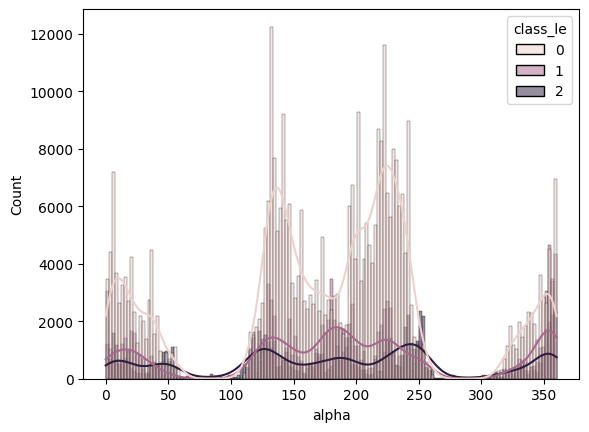

delta


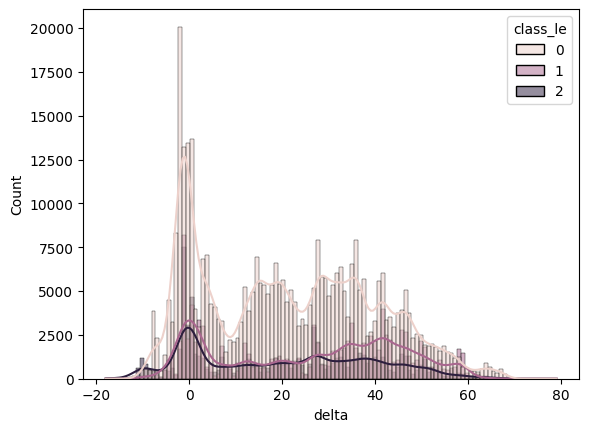

u


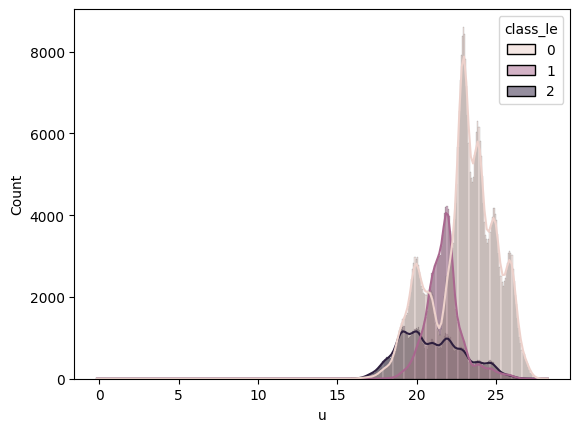

g


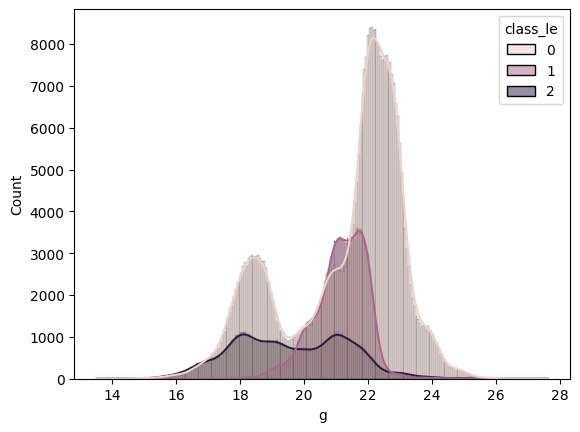

r


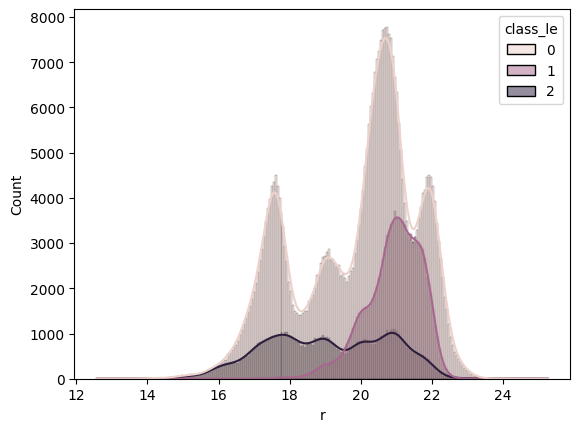

i


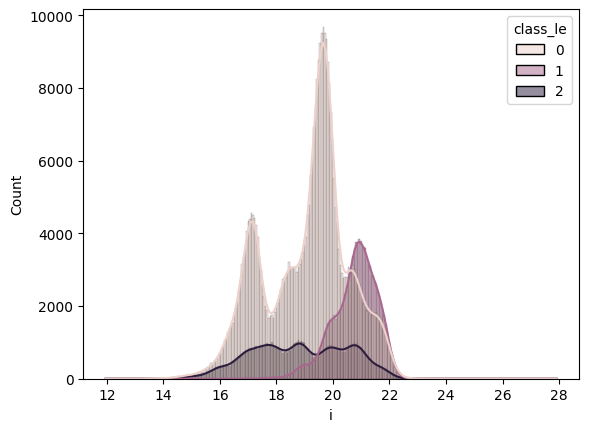

z


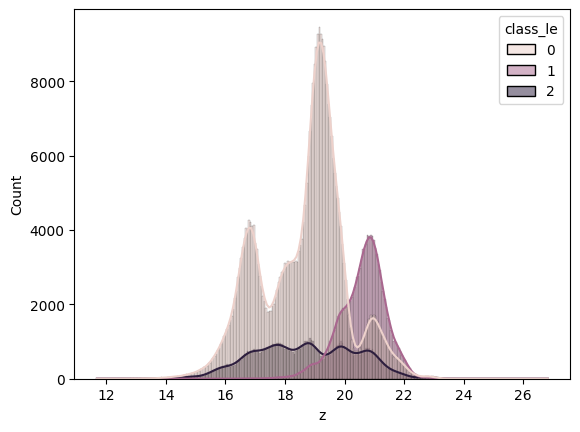

redshift


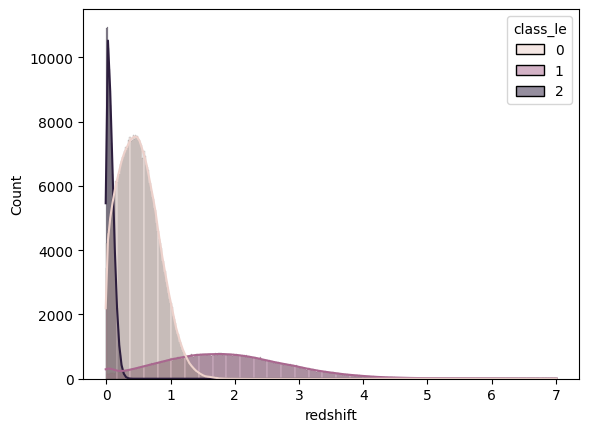

spectral_type_le


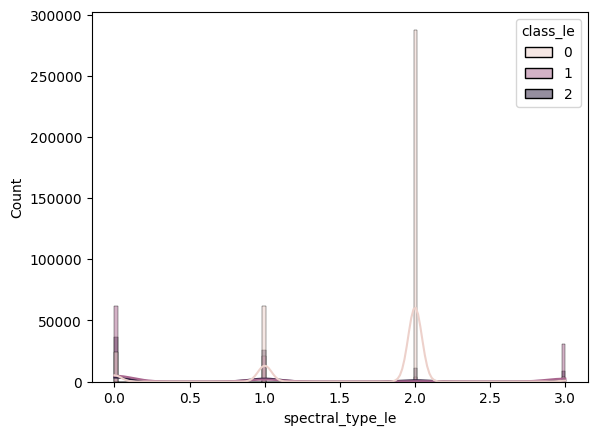

galaxy_population_le


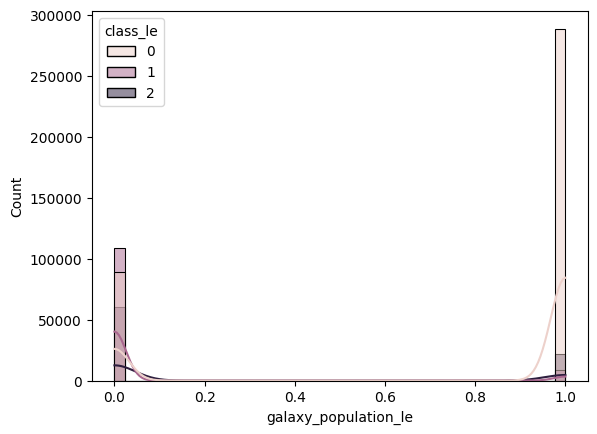

In [36]:
for cols in training_cols:
    print(cols)
    sns.histplot(train_df[training_cols+['class_le']], x=cols, hue='class_le',kde=True)
    plt.show()


class_le


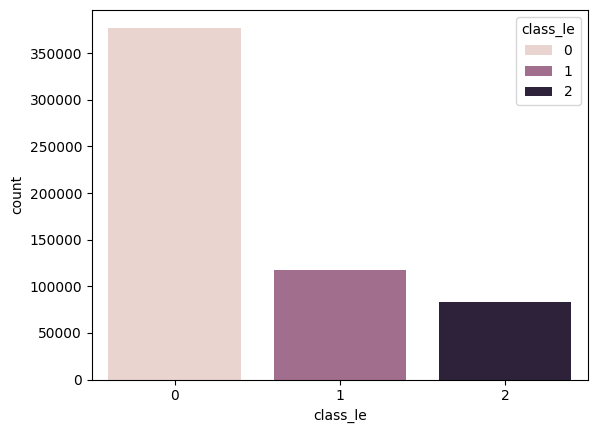

In [44]:
for cols in ['class_le']:
    print(cols)
    sns.countplot(train_df[training_cols+['class_le']], x=cols, hue='class_le')
    plt.show()


In [47]:
from sklearn.model_selection import train_test_split

In [48]:
X, y = train_df[training_cols], train_df['class_le']

In [72]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42 )

In [73]:
X_train.shape

(461877, 10)

In [74]:
X_test.shape

(115470, 10)

In [71]:
import xgboost as xgb
# from sklearn.model_selection import GridSearchCV

In [67]:
# grid = {
#     'n_estimators' :[300,600],
#     'max_depth' : [5,9],
#     'learning_rate' : [0.1,0.05]
# }

# model = xgb.XGBClassifier()

In [68]:
# gscv = GridSearchCV(
#     model, 
#     grid,
#     scoring='accuracy', 
#     cv=3,
#     verbose=4,
#     n_jobs=-1

# )

In [70]:
# gscv.fit(X_train, y_train)

In [75]:
model = xgb.XGBClassifier()

In [76]:
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [81]:
from sklearn.metrics import accuracy_score

In [82]:
y_preds = model.predict(X_test[training_cols])

In [83]:
accuracy_score(y_test,y_preds)

0.9652810253745562

In [84]:
submission_preds = model.predict(test_df[training_cols])

In [88]:
submission_df = pd.DataFrame({
    'id': test_df['id'],
    'class':target_le.inverse_transform(submission_preds)
})

In [89]:
submission_df

,id,class
0,577347,GALAXY
1,577348,GALAXY
2,577349,GALAXY
3,577350,STAR
4,577351,GALAXY
...,...,...
247430,824777,QSO
247431,824778,QSO
247432,824779,GALAXY
247433,824780,QSO


In [90]:
submission_df.to_csv('submission.csv',index=False)

In [91]:
!kaggle competitions submit -c playground-series-s6e6 -f submission.csv  -m "first baseline"

100%|██████████████████████████████████████| 3.09M/3.09M [00:00<00:00, 10.5MB/s]
Successfully submitted to Predicting Stellar Class